In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [12]:
df_train = pd.read_csv('train_landmark_features.csv')
df_test = pd.read_csv('test_landmark_features.csv')

In [13]:
df_train.shape

(3983, 34)

In [14]:
# Menampilkan data yang memiliki missing values di df_train
missing_train = df_train[df_train.isnull().any(axis=1)]
print(missing_train)

# Menampilkan data yang memiliki missing values di df_test
missing_test = df_test[df_test.isnull().any(axis=1)]
print(missing_test)


            D1        D2        D3        D4        D5        D6        D7  \
18    0.194194  0.145969  0.156215  0.144713  0.128288  0.101840  0.071671   
755   0.194660  0.141705  0.155803  0.146894  0.130567  0.101723  0.071605   
875   0.209316  0.140863  0.153868  0.142125  0.124628  0.099999  0.070622   
978   0.214521  0.128758  0.159312  0.148147  0.126231  0.098069  0.068120   
1087  0.207030  0.132004  0.150679  0.142005  0.129253  0.105012  0.074314   
1522  0.197428  0.137662  0.154671  0.144160  0.129382  0.104732  0.073456   
1556  0.205948  0.136895  0.157328  0.146367  0.127328  0.100088  0.069975   
1938  0.194242  0.142394  0.150192  0.141353  0.128944  0.105793  0.076602   
2297  0.194541  0.135691  0.149116  0.141041  0.129090  0.108862  0.078922   
2345  0.202018  0.145410  0.151532  0.140136  0.126476  0.101626  0.073153   
2447  0.191624  0.140121  0.154350  0.145299  0.131005  0.105868  0.074221   
3238  0.195748  0.131172  0.147092  0.140452  0.130499  0.110592

In [15]:
# Menghapus baris dengan nilai NaN dari df_train
df_train_cleaned = df_train.dropna()

# Menghapus baris dengan nilai NaN dari df_test
df_test_cleaned = df_test.dropna()

# Menampilkan hasil setelah penghapusan
print("Dataset train setelah penghapusan missing values:")
print(df_train_cleaned)

print("Dataset test setelah penghapusan missing values:")
print(df_test_cleaned)


Dataset train setelah penghapusan missing values:
            D1        D2        D3        D4        D5        D6        D7  \
0     0.196476  0.141174  0.152380  0.144882  0.129728  0.104423  0.072919   
1     0.197017  0.138700  0.157090  0.147205  0.130027  0.103069  0.071157   
2     0.205371  0.130877  0.152245  0.144959  0.128864  0.102936  0.074437   
3     0.198772  0.137605  0.154716  0.147164  0.129720  0.102496  0.071614   
4     0.198534  0.140274  0.151720  0.144329  0.129644  0.105062  0.073267   
...        ...       ...       ...       ...       ...       ...       ...   
3978  0.185125  0.142344  0.150787  0.143896  0.132357  0.109332  0.077117   
3979  0.180025  0.142519  0.154429  0.147129  0.132543  0.109441  0.075398   
3980  0.187882  0.135997  0.154840  0.148496  0.133252  0.109142  0.074882   
3981  0.191285  0.134543  0.152841  0.145339  0.134126  0.109232  0.074492   
3982  0.192040  0.131243  0.152963  0.144864  0.131952  0.109240  0.077162   

            D

In [6]:
df_train.head()

,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,...,angle1,angle2,angle3,angle4,angle5,angle6,angle7,rahang,atas,label
0,0.196476,0.141174,0.152380,0.144882,0.129728,0.104423,0.072919,0.038322,0.019696,0.040726,...,63.528264,51.486861,74.184182,155.223116,170.297623,169.788924,153.225075,101.244496,68.388956,Heart
1,0.197017,0.138700,0.157090,0.147205,0.130027,0.103069,0.071157,0.036820,0.018915,0.039296,...,64.794898,54.129906,70.967888,157.377048,171.453014,169.406977,153.434949,101.093995,77.513658,Heart
2,0.205371,0.130877,0.152245,0.144959,0.128864,0.102936,0.074437,0.039810,0.020500,0.042205,...,61.865429,49.373542,74.463166,152.940964,172.594637,168.142027,152.318938,106.974563,71.182830,Heart
3,0.198772,0.137605,0.154716,0.147164,0.129720,0.102496,0.071614,0.038291,0.019623,0.040027,...,63.434949,52.717647,72.630687,153.476296,175.333837,165.674469,154.653824,102.502549,76.321648,Heart
4,0.198534,0.140274,0.151720,0.144329,0.129644,0.105062,0.073267,0.037886,0.019285,0.040156,...,65.816770,53.696661,74.243606,154.891796,169.461020,169.187581,158.369113,101.825530,78.234916,Heart


In [16]:
X_train = df_train_cleaned.iloc[:,:-1]
X_test = df_test_cleaned.iloc[:,:-1]
y_train = df_train_cleaned.iloc[:,-1]
y_test = df_test_cleaned.iloc[:,-1]

In [8]:
X_train.head()

,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,...,R10,angle1,angle2,angle3,angle4,angle5,angle6,angle7,rahang,atas
0,0.196476,0.141174,0.152380,0.144882,0.129728,0.104423,0.072919,0.038322,0.019696,0.040726,...,0.698301,63.528264,51.486861,74.184182,155.223116,170.297623,169.788924,153.225075,101.244496,68.388956
1,0.197017,0.138700,0.157090,0.147205,0.130027,0.103069,0.071157,0.036820,0.018915,0.039296,...,0.690383,64.794898,54.129906,70.967888,157.377048,171.453014,169.406977,153.434949,101.093995,77.513658
2,0.205371,0.130877,0.152245,0.144959,0.128864,0.102936,0.074437,0.039810,0.020500,0.042205,...,0.723146,61.865429,49.373542,74.463166,152.940964,172.594637,168.142027,152.318938,106.974563,71.182830
3,0.198772,0.137605,0.154716,0.147164,0.129720,0.102496,0.071614,0.038291,0.019623,0.040027,...,0.698696,63.434949,52.717647,72.630687,153.476296,175.333837,165.674469,154.653824,102.502549,76.321648
4,0.198534,0.140274,0.151720,0.144329,0.129644,0.105062,0.073267,0.037886,0.019285,0.040156,...,0.697368,65.816770,53.696661,74.243606,154.891796,169.461020,169.187581,158.369113,101.825530,78.234916


In [9]:
X_test.head()

,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,...,R10,angle1,angle2,angle3,angle4,angle5,angle6,angle7,rahang,atas
0,0.194991,0.138185,0.151034,0.144000,0.130730,0.106581,0.076179,0.038757,0.019544,0.040313,...,0.714752,70.794442,55.814907,75.281648,157.450493,167.339747,170.836697,165.068583,102.183693,75.581002
1,0.196565,0.142380,0.150493,0.142263,0.128150,0.104636,0.075244,0.039973,0.020296,0.041065,...,0.719101,66.370622,52.379173,74.594843,153.754142,169.835373,170.997525,159.984040,107.831369,74.917379
2,0.204251,0.138127,0.154168,0.144224,0.128096,0.102126,0.072273,0.037377,0.019359,0.040218,...,0.707683,63.918226,51.528752,72.058931,159.202639,173.193832,170.694644,149.726521,102.101373,78.969429
3,0.188359,0.145402,0.157877,0.145909,0.129970,0.103433,0.072939,0.037127,0.018985,0.040055,...,0.705187,65.566371,52.929849,71.254836,156.978341,170.181414,172.797272,155.810486,96.358539,65.318173
4,0.195466,0.140909,0.152691,0.143873,0.129964,0.104771,0.073172,0.039106,0.020049,0.040105,...,0.698400,65.816770,54.266929,74.042530,157.623627,168.750052,172.750232,154.448928,98.374940,73.562618


In [17]:
from sklearn.preprocessing import StandardScaler

# Inisialisasi StandardScaler
scaler = StandardScaler()

# Fit scaler pada X_train dan transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform X_test dengan scaler yang sudah di-fit dari X_train
X_test_scaled = scaler.transform(X_test)


In [18]:
X_train_scaled.shape

(3967, 33)

In [11]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Definisikan rentang parameter untuk SVM
param_grid = {
    'C': [0.1, 1, 10, 100, 1000],
    'kernel': ['rbf'],
    'gamma': ['scale', 'auto', 1, 0.1, 0.01, 0.001],
}

# Inisialisasi model SVM
svc = SVC(probability=True)


# Set up GridSearchCV dengan cross-validation 5-fold
grid_search = GridSearchCV(estimator=svc, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

# Fit grid search pada data training
grid_search.fit(X_train_scaled, y_train)

# Menampilkan hasil terbaik
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score: ", grid_search.best_score_)

# Menggunakan model terbaik untuk prediksi pada data testing
best_svc = grid_search.best_estimator_
y_pred = best_svc.predict(X_test_scaled)

# Evaluasi akurasi model
from sklearn.metrics import accuracy_score
print("Test set accuracy: ", accuracy_score(y_test, y_pred))


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters found:  {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best cross-validation score:  0.5870923477150507
Test set accuracy:  0.5587939698492462


Confusion Matrix:
 [[105  29  37  19  10]
 [ 21 160  12   1   4]
 [ 56  20  76  32  16]
 [ 17   3  34 103  41]
 [  6  12  21  48 112]]


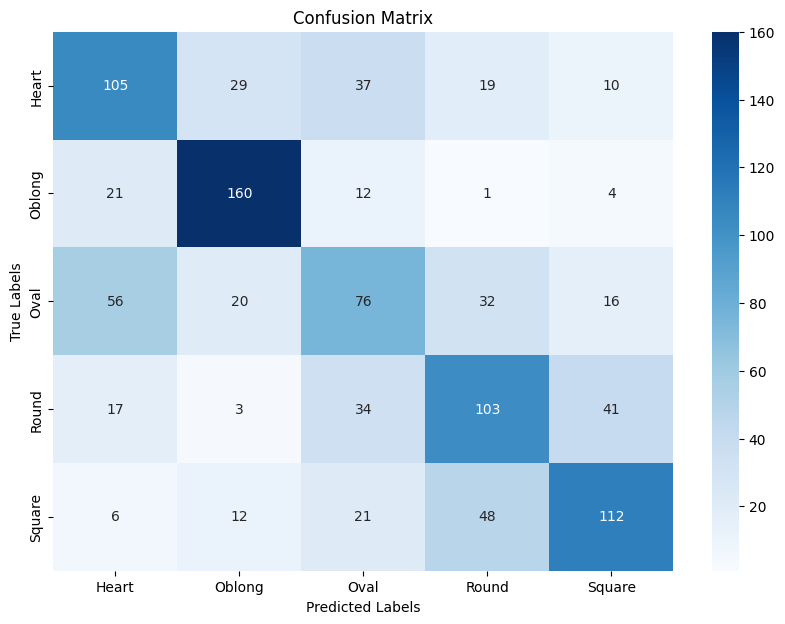

Classification Report:
               precision    recall  f1-score   support

       Heart       0.51      0.53      0.52       200
      Oblong       0.71      0.81      0.76       198
        Oval       0.42      0.38      0.40       200
       Round       0.51      0.52      0.51       198
      Square       0.61      0.56      0.59       199

    accuracy                           0.56       995
   macro avg       0.55      0.56      0.56       995
weighted avg       0.55      0.56      0.56       995



In [12]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Membuat confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
# Visualisasi confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_svc.classes_, yticklabels=best_svc.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Laporan klasifikasi
print("Classification Report:\n", classification_report(y_test, y_pred))

In [13]:
# import joblib

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)  # Fit dan transform data training

# # Simpan scaler ke file
# joblib.dump(scaler, 'scaler.pkl')


In [14]:
# # Simpan model ke file
# joblib.dump(best_svc, 'best_svc_model.pkl')

# print("Model berhasil disimpan!")
